# Your Task:
Implement the Softmax and Prediction functions using either of the following approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

In [1]:
import numpy as np

def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.
    Parameters:
    z (numpy.ndarray): Logits (raw scores) of shape (m, n)
    Returns:
    numpy.ndarray: Softmax probability matrix of shape (m, n)
    """
    # Numerical stabilization: subtract max value per row
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Softmax Test Case
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.
    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)
    Returns:
    numpy.ndarray: Predicted class labels of shape (n,)
    """
    # Calculate logits
    z = np.dot(X, W) + b
    # Use argmax on softmax probabilities or logits (both yield same result)
    predicted_classes = np.argmax(softmax(z), axis=1)
    return predicted_classes

# Prediction Test Case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Softmax function passed the test case!
Predicted class labels: [1 1 0]


# Your Task:
Implement the Loss and Cost functions using either of the following approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

In [2]:
import numpy as np

def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss for a single sample or batch.
    Parameters:
    y_pred (numpy.ndarray): Predicted probabilities.
    y (numpy.ndarray): True labels (one-hot encoded).
    """
    # Clip values to avoid log(0) which results in infinity
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]
    return loss

# Test case for Loss Function
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([[0.9, 0.05, 0.05], [0.1, 0.85, 0.05], [0.05, 0.1, 0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9], [0.1, 0.05, 0.85], [0.85, 0.1, 0.05]])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, f"Test failed: {loss_correct:.4f} >= {loss_incorrect:.4f}"
print(f"Cross-Entropy Loss (Correct): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect): {loss_incorrect:.4f}")

def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost over all samples.
    """
    n = X.shape[0]
    # Calculate logits
    z = np.dot(X, W) + b
    # Calculate probabilities using previously defined softmax
    y_pred = softmax(z)
    # Calculate total cross-entropy loss
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n

# Test case for Cost Function
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, f"Test failed: {cost_incorrect} <= {cost_correct}"
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cross-Entropy Loss (Correct): 0.1435
Cross-Entropy Loss (Incorrect): 2.9957
Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


# Your Task:
Implement the Compute Gradients and Gradient Descent functions using either of the following
approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

In [3]:
import numpy as np

def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function with respect to weights and biases.
    """
    n = X.shape[0]
    # Calculate probabilities
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    # Gradient calculation
    error = y_pred - y
    grad_W = np.dot(X.T, error) / n
    grad_b = np.sum(error, axis=0) / n

    return grad_W, grad_b

# Test case for compute gradient softmax Function
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Verification
z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), "Test failed: Gradients w.r.t. W are not equal."
assert np.allclose(grad_b, grad_b_manual), "Test failed: Gradients w.r.t. b are not equal."

print("Gradient w.r.t. W:\n", grad_W)
print("Gradient w.r.t. b:\n", grad_b)
print("Test passed!\n")

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.
    """
    cost_history = []
    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Track cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:.4f}")

    return W, b, cost_history

Gradient w.r.t. W:
 [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b:
 [-0.03290036  0.02484708  0.00805328]
Test passed!



# Your Task:
Implement the load and prepare mnist; and plot sample images using either of the following
approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Whichever appraoch you pick you are expected to perform following:
• ✓ Loads MNIST CSV file into a Pandas DataFrame.
• ✓ Extracts labels (y) and image pixel values (X).
• ✓ Normalizes pixel values (optional, but helps convergence).
• ✓ Splits data into training and test sets (default: 80% train, 20% test).
• ✓ Plots one example image per digit (0-9) for visualization.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    Arguments:
    X (np.ndarray): Feature matrix containing pixel values.
    y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)  # Get unique class labels
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]  # Find first occurrence of the class
        image = X[index].reshape(28, 28)  # Reshape 1D array to 28x28
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets, and plots one image per class.
    """
    # Load dataset
    df = pd.read_csv(csv_file)

    # Separate labels and features
    y = df.iloc[:, 0].values  # First column is the label
    X = df.iloc[:, 1:].values  # Remaining columns are pixel values

    # Normalize pixel values
    X = X / 255.0  # Scale values between 0 and 1

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Plot one sample image per class
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

### Step 1: Load and Prepare Data
We will use the small MNIST dataset provided in the sample data folder.

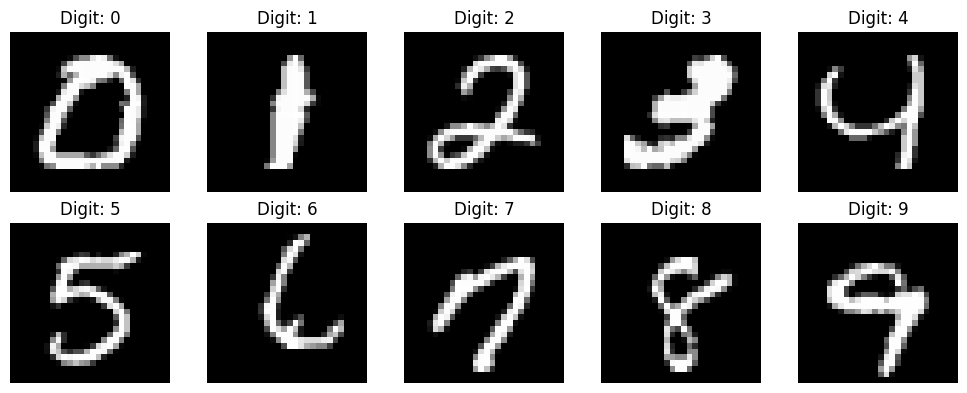

Training data shape: (15999, 784)
Test data shape: (4000, 784)


In [6]:
# Load and visualize the data
csv_path = '/content/sample_data/mnist_train_small.csv'
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_path)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

### Step 2: One-Hot Encoding and Initialization
Softmax regression requires the true labels `y` to be one-hot encoded for the cost function.

In [7]:
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

num_classes = 10
n_features = X_train.shape[1]

# One-hot encode training labels
y_train_oh = one_hot_encode(y_train, num_classes)

# Initialize weights and biases with small random values
np.random.seed(42)
W = np.random.randn(n_features, num_classes) * 0.01
b = np.zeros(num_classes)

### Step 3: Model Training
Now we run the Gradient Descent algorithm using a learning rate ($\\alpha$) of 0.1.

Iteration 0: Cost 2.2194
Iteration 100: Cost 0.5985
Iteration 200: Cost 0.4787
Iteration 300: Cost 0.4287
Iteration 400: Cost 0.3996
Iteration 500: Cost 0.3800
Iteration 600: Cost 0.3654
Iteration 700: Cost 0.3541
Iteration 800: Cost 0.3450
Iteration 900: Cost 0.3374


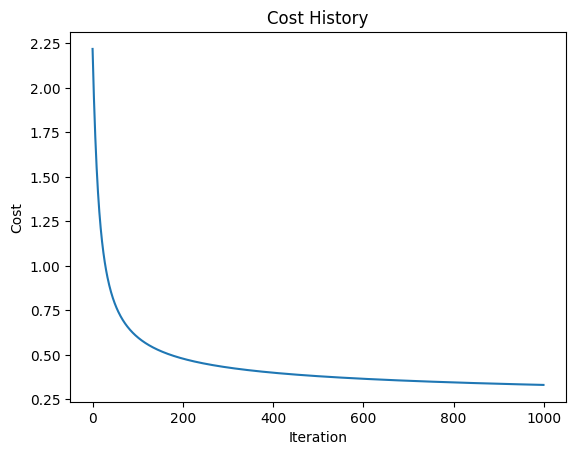

In [8]:
# Hyperparameters
alpha = 0.1
n_iter = 1000

# Train the model
W_trained, b_trained, cost_history = gradient_descent_softmax(
    X_train, y_train_oh, W, b, alpha, n_iter, show_cost=True
)

# Plot cost history
plt.plot(cost_history)
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

### Step 4: Evaluation
Finally, we evaluate the accuracy on the test set.

In [9]:
# Predict on test set
y_pred = predict_softmax(X_test, W_trained, b_trained)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 89.92%
